In [31]:
R.version.string

[1] "R version 4.4.2 (2024-10-31)"

In [1]:
# ----------- Load Libraries -----------
library(phyloseq)
library(tidyr)
library(microbiome)
library(dplyr)
library(broom)
library(openxlsx)
library(tibble)
library(emmeans)
library(ggpubr)
library(vegan)
library(patchwork)
library(compositions)

Loading required package: ggplot2


microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2022 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>



Attaching package: ‘microbiome’


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:base’:

    transform



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘broom’ was built under R version 4.4.3”
Warning message:
“package ‘emmeans’ was built under R version 4.4.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Loading required package: permute


Attaching package: ‘vegan’


The following object is masked from ‘package:microbiome’:

    diversity


Welcome to compositions, a package for compositional data a

In [10]:
# ----------- Load Phyloseq and Tree -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.rds")
tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_gp_decontam_rooted.rds")

# Rename ASVs to consistent format
asv_seqs <- taxa_names(ps)
names(asv_seqs) <- paste0("ASV", seq_along(asv_seqs))
taxa_names(ps) <- names(asv_seqs)
tree$tip.label <- names(asv_seqs)
phy_tree(ps) <- tree

# ----------- Extract Metadata -----------
meta <- as(sample_data(ps), "data.frame")

# ----------- Exclude Mock Samples Globally -----------
mock_samples <- grep("mock-synthetic-ZYMO", rownames(meta), value = TRUE)

# Remove mocks from phyloseq object
ps <- prune_samples(!sample_names(ps) %in% mock_samples, ps)

# ----------- Refresh Metadata After Pruning -----------
meta <- as(sample_data(ps), "data.frame")

# ----------- Generate Numeric Extraction Date If Missing -----------
if (!"ExtractionDate_numeric" %in% colnames(meta)) {
  meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%y")
  meta$ExtractionDate_numeric <- as.numeric(meta$ExtractionDate - min(meta$ExtractionDate, na.rm = TRUE))
}

# ----------- Define Paths -----------
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/Figures"
path.stat <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"


In [16]:
# --------- Define Variables --------
vars <- c(
  "Fibrinogen_InflamStat", 
  "Haptoglobin_InflamStat", 
  "Parity", 
  "BCS", 
  "DIM_Collected", 
  "ExtractionDate_numeric", 
  "Cow_ID"
)


In [17]:
# ----------- Alpha Diversity -----------

alpha_df <- suppressWarnings(estimate_richness(ps, measures = c("Observed", "Shannon", "Simpson")))
alpha_df$Evenness <- evenness(ps, index = "pielou")$pielou

# ----------- Metadata Variables to Include -----------
meta <- data.frame(sample_data(ps))
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%y")
meta$ExtractionDate_numeric <- as.numeric(meta$ExtractionDate - min(meta$ExtractionDate, na.rm = TRUE))
meta$Cow_ID <- as.factor(meta$Cow_ID)

# ----------- Merge Metadata with Alpha Diversity -----------
alpha_df <- cbind(alpha_df, meta[, vars])

# ----------- Clean and Format Variables -----------
metrics <- c("Observed", "Shannon", "Simpson", "Evenness")
alpha_df <- alpha_df[complete.cases(alpha_df[, c(metrics, vars)]), ]

alpha_df$Parity <- as.factor(alpha_df$Parity)
alpha_df$BCS <- as.factor(alpha_df$BCS)
alpha_df$Fibrinogen_InflamStat <- factor(alpha_df$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))
alpha_df$Haptoglobin_InflamStat <- factor(alpha_df$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))
alpha_df$Cow_ID <- as.factor(alpha_df$Cow_ID)


In [24]:
# ----------- Multivariate Linear Models -----------
lm_results <- lapply(metrics, function(metric) {
  model <- lm(
    formula = as.formula(paste(metric, "~ Fibrinogen_InflamStat + Haptoglobin_InflamStat + Parity + BCS + DIM_Collected + ExtractionDate_numeric + Cow_ID")),
    data = alpha_df
  )
  tidy_model <- tidy(model)
  tidy_model$Metric <- metric
  tidy_model$R2 <- summary(model)$r.squared
  tidy_model
})

# Combine into single data frame
lm_df <- bind_rows(lm_results)

# ----------- Adjust P-values (FDR) -----------
lm_df <- lm_df %>%
  group_by(Metric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# ----------- Effect Size Summaries -----------
summary_list <- list()
for (var in vars) {
  if (is.numeric(alpha_df[[var]]) || (is.factor(alpha_df[[var]]) && nlevels(alpha_df[[var]]) > 10)) next
  for (metric in metrics) {
    medians <- tapply(alpha_df[[metric]], alpha_df[[var]], median)
    summary_list[[paste(metric, var, sep = "_")]] <- medians
  }
}
effect_sizes <- bind_rows(summary_list, .id = "Metric_Variable")


In [25]:
# ----------- Define Output File Path -----------
Alpha_multivariate <- file.path(path.stat, "Alpha_diversity_multivariate.xlsx")

# ----------- Export to Excel -----------
write.xlsx(
  list(
    "Linear_Model_Stats" = lm_df,
    "Effect_Size_Summaries" = effect_sizes
  ),
  file = Alpha_multivariate,
  rowNames = FALSE
)


In [26]:

# ----------- Univariate Linear Models -----------
lm_uni_results <- list()

for (metric in metrics) {
  for (var in vars) {
    df_sub <- alpha_df[complete.cases(alpha_df[, c(metric, var)]), ]
    
    # Skip if factor has <2 levels
    if (is.factor(df_sub[[var]]) && nlevels(df_sub[[var]]) < 2) next
    
    model <- lm(as.formula(paste(metric, "~", var)), data = df_sub)
    tidy_model <- broom::tidy(model)
    tidy_model$Metric <- metric
    tidy_model$Variable <- var
    tidy_model$R2 <- summary(model)$r.squared
    
    lm_uni_results[[paste(metric, var, sep = "_")]] <- tidy_model
  }
}

lm_uni_df <- bind_rows(lm_uni_results)

# ----------- Adjust P-values (FDR) by Metric -----------
lm_uni_df <- lm_uni_df %>%
  group_by(Metric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# ----------- Effect Size Summaries -----------
summary_list_uni <- list()
for (var in vars) {
  if (is.numeric(alpha_df[[var]]) || (is.factor(alpha_df[[var]]) && nlevels(alpha_df[[var]]) > 10)) next
  for (metric in metrics) {
    medians <- tapply(alpha_df[[metric]], alpha_df[[var]], median)
    summary_list_uni[[paste(metric, var, sep = "_")]] <- medians
  }
}
effect_sizes_uni <- bind_rows(summary_list_uni, .id = "Metric_Variable")


In [27]:
# ----------- Define Output File Path for Univariate Results -----------
Alpha_univariate <- file.path(path.stat, "Alpha_diversity_univariate.xlsx")

# ----------- Export Univariate Results to Excel -----------
write.xlsx(
  list(
    "Linear_Model_Stats" = lm_uni_df,
    "Effect_Size_Summaries" = effect_sizes_uni
  ),
  file = Alpha_univariate,
  rowNames = FALSE
)


In [6]:
# ----------- Beta Diversity Distance Calculations -----------
ps_beta <- prune_samples(rownames(meta), ps)
sample_data(ps_beta) <- sample_data(meta)

bray_dist <- phyloseq::distance(ps_beta, method = "bray")
otu_clr <- as.data.frame(otu_table(ps_beta))
if (taxa_are_rows(ps_beta)) otu_clr <- t(otu_clr)
otu_clr <- clr(otu_clr + 1e-6)
aitchison_dist <- dist(otu_clr)
wunifrac_dist <- phyloseq::distance(ps_beta, method = "wunifrac")
uunifrac_dist <- phyloseq::distance(ps_beta, method = "unifrac")


In [12]:
## Beta
# ----------- Multivariate PERMANOVA -----------
run_permanova <- function(dist, meta, vars) {
  formula <- as.formula(paste("dist ~", paste(vars, collapse = " + ")))
  adonis2(formula, data = meta, permutations = 999, by = "margin")
}

# Run for all distances
res_bray <- run_permanova(bray_dist, meta, vars)
res_aitch <- run_permanova(aitchison_dist, meta, vars)
res_wuni <- run_permanova(wunifrac_dist, meta, vars)
res_uuni <- run_permanova(uunifrac_dist, meta, vars)

# Format results into detailed table
format_adonis <- function(adonis_result, distance_name) {
  df <- as.data.frame(adonis_result)
  df$Variable <- rownames(df)
  
  df %>%
    filter(!Variable %in% c("Residual", "Total")) %>%
    select(Variable, R2 = R2, p_value = `Pr(>F)`) %>%
    mutate(Distance = distance_name)
}

# Combine and correct p-values
df_beta_multi <- bind_rows(
  format_adonis(res_bray, "Bray–Curtis"),
  format_adonis(res_aitch, "Aitchison"),
  format_adonis(res_wuni, "Weighted UniFrac"),
  format_adonis(res_uuni, "Unweighted UniFrac")
) %>%
  arrange(Distance, Variable) %>%
  group_by(Distance) %>%
  mutate(FDR = p.adjust(p_value, method = "fdr")) %>%
  ungroup() %>%
  select(Distance, Variable, R2, p_value, FDR)

# ----------- Save as Excel File -----------
library(openxlsx)
write.xlsx(df_beta_multi, file = file.path(path.stat, "BetaDiversity_PERMANOVA_multivariate.xlsx"))


In [15]:
# ----------- Beta Diversity: Univariate PERMANOVA -----------
distance_list <- list(
  "Bray–Curtis" = as.matrix(bray_dist),
  "Aitchison" = as.matrix(aitchison_dist),
  "Weighted UniFrac" = as.matrix(wunifrac_dist),
  "Unweighted UniFrac" = as.matrix(uunifrac_dist)
)

permanova_uni_list <- list()

for (dist_name in names(distance_list)) {
  dist_mat <- distance_list[[dist_name]]
  
  for (var in vars) {
    # Subset metadata to non-missing values for the current variable
    sub_meta <- meta[!is.na(meta[[var]]), ]
    sub_ids <- rownames(sub_meta)
    
    # Subset distance matrix accordingly
    dist_sub <- as.dist(dist_mat[sub_ids, sub_ids])
    
    # Run adonis2
    fmla <- as.formula(paste("dist_sub ~", var))
    ad <- adonis2(fmla, data = sub_meta, permutations = 999)
    
    permanova_uni_list[[paste(dist_name, var, sep = "_")]] <- data.frame(
      Distance = dist_name,
      Variable = var,
      R2 = ad$R2[1],
      p_value = ad$`Pr(>F)`[1]
    )
  }
}

# Combine results and adjust p-values
df_beta_uni <- bind_rows(permanova_uni_list) %>%
  group_by(Distance) %>%
  mutate(FDR = p.adjust(p_value, method = "fdr")) %>%
  ungroup()

# ----------- Save to Excel -----------
write.xlsx(df_beta_uni, file = file.path(path.stat, "BetaDiversity_PERMANOVA_univariate.xlsx"))


In [109]:
### Identifying confounder for Alpha Diversity

In [22]:
# Define covariates and inflammation variables
covariates <- c("Parity", "BCS", "DIM_Collected", "ExtractionDate_numeric")
inflammation_vars <- c("Fibrinogen_InflamStat", "Haptoglobin_InflamStat")

inflam_assoc <- list()

for (inflamm in inflammation_vars) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(inflamm, "~", covar))
    
    # Try-catch to avoid breaking on errors
    try({
      model <- glm(formula_str, data = alpha_df, family = binomial, control = list(maxit = 50))
      tidy_model <- broom::tidy(model)
      tidy_model$inflammation <- inflamm
      tidy_model$covariate <- covar
      inflam_assoc[[paste(inflamm, covar, sep = "_")]] <- tidy_model
    }, silent = TRUE)
  }
}

# Combine and clean results
inflam_df <- bind_rows(inflam_assoc) %>%
  filter(term != "(Intercept)") %>%
  select(inflammation, covariate, term, estimate, p.value)

print(inflam_df)

# Corrected file export
write.xlsx(inflam_df,
           file = file.path(path.stat, "inflammation_covariate_association_Alpha.xlsx"),
           rowNames = FALSE)


# A tibble: 32 × 5
   inflammation          covariate term    estimate p.value
   <chr>                 <chr>     <chr>      <dbl>   <dbl>
 1 Fibrinogen_InflamStat Parity    Parity2   -0.709  0.152 
 2 Fibrinogen_InflamStat Parity    Parity3   -0.709  0.215 
 3 Fibrinogen_InflamStat Parity    Parity4   -1.40   0.0245
 4 Fibrinogen_InflamStat Parity    Parity5   15.4    0.990 
 5 Fibrinogen_InflamStat Parity    Parity6   -0.486  0.611 
 6 Fibrinogen_InflamStat Parity    Parity7  -17.7    0.992 
 7 Fibrinogen_InflamStat BCS       BCS2.5    33.1    0.989 
 8 Fibrinogen_InflamStat BCS       BCS2.75   18.5    0.991 
 9 Fibrinogen_InflamStat BCS       BCS3      15.9    0.993 
10 Fibrinogen_InflamStat BCS       BCS3.25   17.5    0.992 
# ℹ 22 more rows


In [24]:
# Define diversity metrics
metrics <- c("Observed", "Shannon", "Simpson", "Evenness")

# Empty list to store results
diversity_assoc <- list()

for (metric in metrics) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(metric, "~", covar))
    model <- lm(formula_str, data = alpha_df)
    tidy_model <- tidy(model)
    tidy_model$diversity_metric <- metric
    tidy_model$covariate <- covar
    diversity_assoc[[paste(metric, covar, sep = "_")]] <- tidy_model
  }
}

# Combine and filter
diversity_df <- bind_rows(diversity_assoc) %>%
  filter(term != "(Intercept)") %>%
  select(diversity_metric, covariate, term, estimate, p.value)

print(diversity_df)
# Save to Excel
write.xlsx(diversity_df,
           file = file.path(path.stat, "AlphaDiversity_Covariate_Association.xlsx"),
           rowNames = FALSE)


# A tibble: 64 × 5
   diversity_metric covariate term    estimate  p.value
   <chr>            <chr>     <chr>      <dbl>    <dbl>
 1 Observed         Parity    Parity2   -14.1  0.000156
 2 Observed         Parity    Parity3    -6.62 0.123   
 3 Observed         Parity    Parity4   -15.8  0.00122 
 4 Observed         Parity    Parity5   -11.2  0.196   
 5 Observed         Parity    Parity6    -9.67 0.185   
 6 Observed         Parity    Parity7    -5.50 0.645   
 7 Observed         BCS       BCS2.5    -22.0  0.191   
 8 Observed         BCS       BCS2.75    -9.69 0.442   
 9 Observed         BCS       BCS3      -11.2  0.384   
10 Observed         BCS       BCS3.25    -7.41 0.550   
# ℹ 54 more rows


In [30]:
# ------- Counfounding factor in Alpha diversity ------
# Step 1: Filter significant terms (p < 0.05)
sig_inflam <- inflam_df %>%
  filter(p.value < 0.05)

sig_diversity <- diversity_df %>%
  filter(p.value < 0.05)

# Step 2: Join on covariate + term to find overlap
confounders <- inner_join(sig_inflam, sig_diversity,
                          by = c("covariate", "term"))

# Step 3: View potential confounders
confounders %>%
  select(covariate, term, inflammation, diversity_metric, 
         estimate_inflam = estimate.x, p_inflam = p.value.x,
         estimate_diversity = estimate.y, p_diversity = p.value.y)

# Save the table
write.xlsx(confounders,
           file = file.path(path.stat, "Potential_Confounders_Alpha_Diversity_Inflammation.xlsx"),
           rowNames = FALSE)


covariate,term,inflammation,diversity_metric,estimate_inflam,p_inflam,estimate_diversity,p_diversity
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Parity,Parity4,Fibrinogen_InflamStat,Observed,-1.40179855,0.02450520,-1.577778e+01,0.0012182071
Parity,Parity4,Fibrinogen_InflamStat,Shannon,-1.40179855,0.02450520,-2.295524e-01,0.0022924655
Parity,Parity4,Fibrinogen_InflamStat,Evenness,-1.40179855,0.02450520,-2.125998e-02,0.0143930036
ExtractionDate_numeric,ExtractionDate_numeric,Fibrinogen_InflamStat,Observed,-0.03195048,0.00203986,-2.638986e-01,0.0006053261
ExtractionDate_numeric,ExtractionDate_numeric,Fibrinogen_InflamStat,Shannon,-0.03195048,0.00203986,-3.852018e-03,0.0012335954
ExtractionDate_numeric,ExtractionDate_numeric,Fibrinogen_InflamStat,Simpson,-0.03195048,0.00203986,-1.424195e-04,0.0053943422
ExtractionDate_numeric,ExtractionDate_numeric,Fibrinogen_InflamStat,Evenness,-0.03195048,0.00203986,-3.629813e-04,0.0084835738


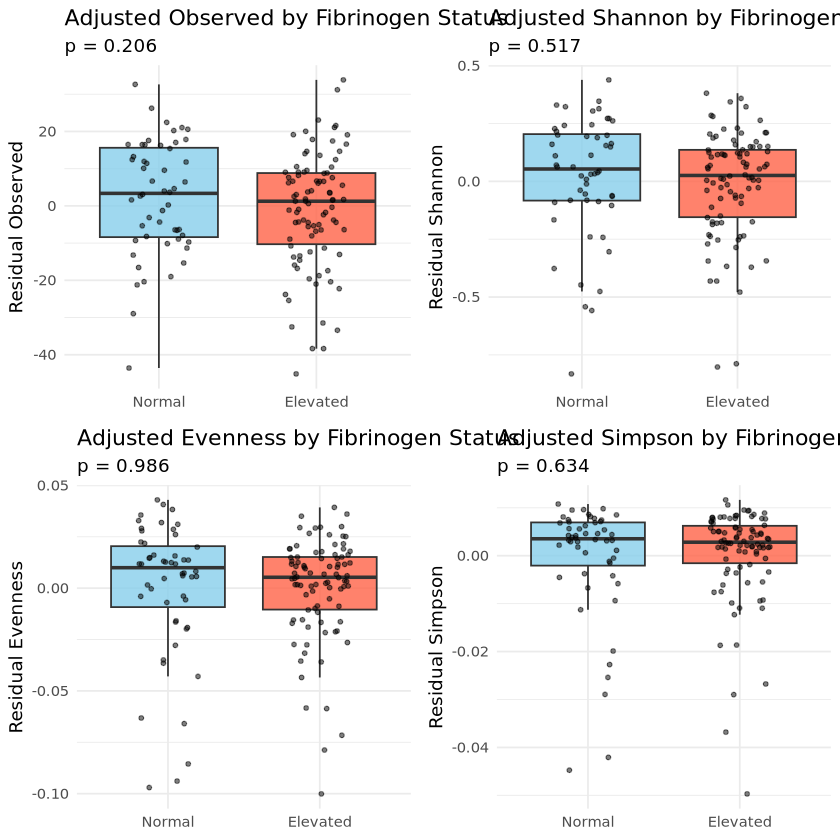

In [42]:
# ------- Adjusted Aplha indices for Fibrinogen ------
library(readxl)

# ----------- Load Confounder Table -----------
conf_tbl <- read_xlsx(file.path(path.stat, "Potential_Confounders_Alpha_Diversity_Inflammation.xlsx"))

# ----------- Subset for Fibrinogen -----------
conf_fib <- conf_tbl %>% filter(inflammation == "Fibrinogen_InflamStat")

# ----------- Ensure Fibrinogen is a factor -----------
alpha_df$Fibrinogen_InflamStat <- factor(alpha_df$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Initialize Storage -----------
residual_plots_fib <- list()
t_tests_fib <- list()

# ----------- Loop Through Diversity Metrics -----------
for (metric in unique(conf_fib$diversity_metric)) {
  confounders <- unique(conf_fib %>% filter(diversity_metric == metric) %>% pull(covariate))
  if (length(confounders) == 0) next
  
  formula_str <- paste0(metric, " ~ ", paste(confounders, collapse = " + "))
  model <- lm(as.formula(formula_str), data = alpha_df)
  
  resid_col <- paste0(metric, "_resid_fib")
  alpha_df[[resid_col]] <- resid(model)
  
  ttest <- t.test(alpha_df[[resid_col]] ~ alpha_df$Fibrinogen_InflamStat)
  pval <- signif(ttest$p.value, 3)
  t_tests_fib[[metric]] <- tidy(ttest)
  
  p <- ggplot(alpha_df, aes(x = Fibrinogen_InflamStat, y = .data[[resid_col]], fill = Fibrinogen_InflamStat)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.8) +
    geom_jitter(width = 0.2, size = 1, alpha = 0.5) +
    labs(title = paste("Adjusted", metric, "by Fibrinogen Status"),
         subtitle = paste("p =", pval),
         x = NULL, y = paste("Residual", metric)) +
    scale_fill_manual(values = c("Normal" = "skyblue", "Elevated" = "tomato")) +
    theme_minimal() +
    theme(legend.position = "none")
  
  residual_plots_fib[[metric]] <- p
}

# ----------- Combine and Save Plots -----------
p_comb_fib <- ggarrange(plotlist = residual_plots_fib, ncol = 2, nrow = ceiling(length(residual_plots_fib) / 2))
ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Fibrinogen.tiff"),
       plot = p_comb_fib, dpi = 300, width = 10, height = 8)
ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Fibrinogen.png"),
       plot = p_comb_fib, dpi = 300, width = 10, height = 8)
print(p_comb_fib)
# ----------- Save t-test Results -----------
t_test_df_fib <- bind_rows(t_tests_fib, .id = "Metric")
write.csv(t_test_df_fib, file = file.path(path.stat, "AlphaDiversity_Adjusted_Fibrinogen_Ttest.csv"), row.names = FALSE)


No confounders found for Observed - using unadjusted model

No confounders found for Shannon - using unadjusted model

No confounders found for Simpson - using unadjusted model

No confounders found for Evenness - using unadjusted model



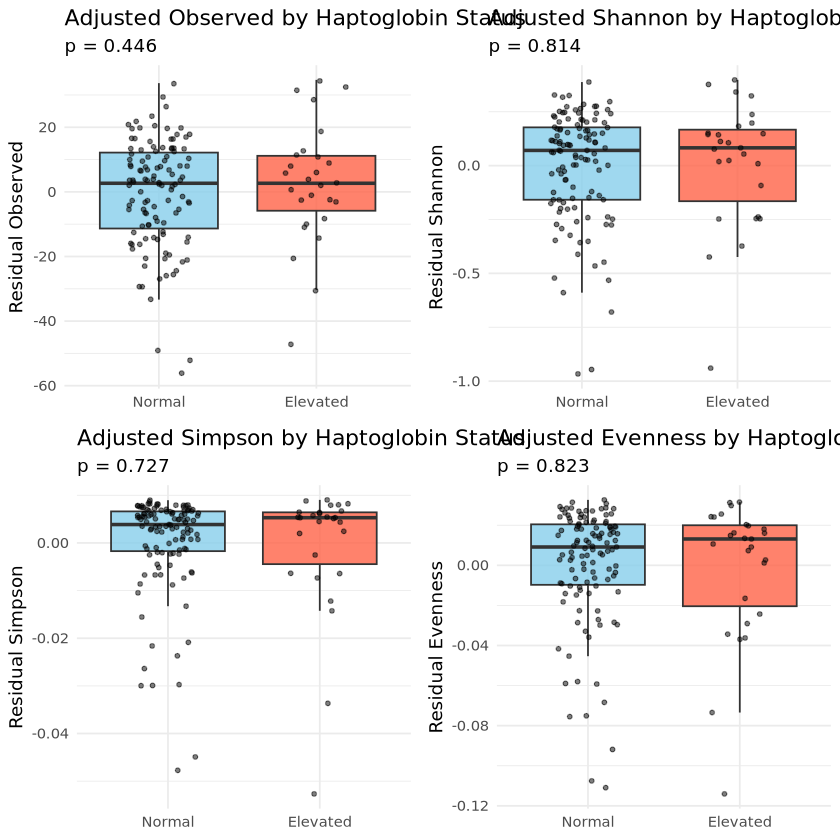

In [43]:
# ------- Adjusted Alpha indices for Haptoglobin -----
# ----------- Load Confounder Table -----------
conf_tbl <- read_xlsx(file.path(path.stat, "Potential_Confounders_Alpha_Diversity_Inflammation.xlsx"))

# ----------- Subset for Haptoglobin -----------
conf_hapto <- conf_tbl %>% filter(inflammation == "Haptoglobin_InflamStat")

# ----------- Ensure Haptoglobin is a factor -----------
alpha_df$Haptoglobin_InflamStat <- factor(alpha_df$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Initialize Storage -----------
residual_plots_hapto <- list()
t_tests_hapto <- list()

# ----------- Define Diversity Metrics -----------
metrics <- c("Observed", "Shannon", "Simpson", "Evenness")

# ----------- Loop Through Diversity Metrics -----------
for (metric in metrics) {
  confounders <- unique(conf_hapto %>% filter(diversity_metric == metric) %>% pull(covariate))
  
  # Build formula string
  if (length(confounders) == 0) {
    message(paste("No confounders found for", metric, "- using unadjusted model"))
    formula_str <- paste0(metric, " ~ 1")  # intercept-only model
  } else {
    formula_str <- paste0(metric, " ~ ", paste(confounders, collapse = " + "))
  }
  
  # Fit model and extract residuals
  model <- lm(as.formula(formula_str), data = alpha_df)
  resid_col <- paste0(metric, "_resid_hapto")
  alpha_df[[resid_col]] <- resid(model)
  
  # Run t-test
  ttest <- t.test(alpha_df[[resid_col]] ~ alpha_df$Haptoglobin_InflamStat)
  pval <- signif(ttest$p.value, 3)
  t_tests_hapto[[metric]] <- tidy(ttest)
  
  # Plot
  p <- ggplot(alpha_df, aes(x = Haptoglobin_InflamStat, y = .data[[resid_col]], fill = Haptoglobin_InflamStat)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.8) +
    geom_jitter(width = 0.2, size = 1, alpha = 0.5) +
    labs(title = paste("Adjusted", metric, "by Haptoglobin Status"),
         subtitle = paste("p =", pval),
         x = NULL, y = paste("Residual", metric)) +
    scale_fill_manual(values = c("Normal" = "skyblue", "Elevated" = "tomato")) +
    theme_minimal() +
    theme(legend.position = "none")
  
  residual_plots_hapto[[metric]] <- p
}

# ----------- Filter out NULLs (if any) -----------
residual_plots_hapto <- residual_plots_hapto[!sapply(residual_plots_hapto, is.null)]

# ----------- Only plot if at least one exists -----------
if (length(residual_plots_hapto) > 0) {
  p_comb_hapto <- ggarrange(plotlist = residual_plots_hapto,
                            ncol = 2,
                            nrow = ceiling(length(residual_plots_hapto) / 2))
  
  ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Haptoglobin.tiff"),
         plot = p_comb_hapto, dpi = 300, width = 10, height = 8)
  
  ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Haptoglobin.png"),
         plot = p_comb_hapto, dpi = 300, width = 10, height = 8)
  
  print(p_comb_hapto)
} else {
  warning("No residual plots generated for Haptoglobin. Check if diversity metrics are available.")
}

# ----------- Save t-test Results -----------
t_test_df_hapto <- bind_rows(t_tests_hapto, .id = "Metric")
write.csv(t_test_df_hapto,
          file = file.path(path.stat, "AlphaDiversity_Adjusted_Haptoglobin_Ttest.csv"),
          row.names = FALSE)


In [44]:
### Identifying confounder for Beta Diversity

In [66]:
# ----------- Define Covariates and Inflammation Variables -----------
covariates <- c("Parity", "BCS", "DIM_Collected", "ExtractionDate_numeric")
inflammation_vars <- c("Fibrinogen_InflamStat", "Haptoglobin_InflamStat")

# ----------- Ensure Inflammation Variables are Binary Factors -----------
alpha_df$Fibrinogen_InflamStat <- factor(alpha_df$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))
alpha_df$Haptoglobin_InflamStat <- factor(alpha_df$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Run Logistic Regressions -----------
inflam_assoc <- list()

for (inflamm in inflammation_vars) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(inflamm, "~", covar))
    
    # Fit model
    model <- glm(formula_str, data = alpha_df, family = binomial)
    tidy_model <- tidy(model)
    
    # Annotate with identifiers
    tidy_model$inflammation <- inflamm
    tidy_model$covariate <- covar
    
    # Store results
    inflam_assoc[[paste(inflamm, covar, sep = "_")]] <- tidy_model
  }
}

# ----------- Combine and Filter for p < 0.05 -----------
inflam_df <- bind_rows(inflam_assoc) %>%
  filter(term != "(Intercept)") %>%
  group_by(inflammation, covariate) %>%
  summarise(min_p_inflam = min(p.value, na.rm = TRUE), .groups = "drop") %>%
  filter(min_p_inflam < 0.05)

# ----------- Save to Excel-----------
write.xlsx(inflam_df, file = file.path(path.stat, "Inflammation_Covariate_Association_Beta.xlsx"), rowNames = FALSE)

# ----------- Optional: View Output -----------
print(inflam_df)


# A tibble: 2 × 3
  inflammation          covariate              min_p_inflam
  <chr>                 <chr>                         <dbl>
1 Fibrinogen_InflamStat ExtractionDate_numeric      0.00204
2 Fibrinogen_InflamStat Parity                      0.0245 


In [64]:
# ----------- Load Required Libraries -----------
library(vegan)
library(dplyr)

# ----------- Define Covariates and Distance Matrices -----------
covariates <- c("Parity", "BCS", "DIM_Collected", "ExtractionDate_numeric")
distances <- list(
  Bray = bray_dist,
  Aitchison = aitchison_dist,
  WUniFrac = wunifrac_dist,
  UUniFrac = uunifrac_dist
)

# ----------- Run PERMANOVA for Each Covariate and Distance -----------
beta_confounders <- list()

for (dist_name in names(distances)) {
  dist <- distances[[dist_name]]
  
  for (covar in covariates) {
    formula <- as.formula(paste("dist ~", covar))
    
    # Run adonis2 safely
    try({
      ad <- adonis2(formula, data = meta, permutations = 999)
      result <- data.frame(
        Distance = dist_name,
        Covariate = covar,
        R2 = ad[[1, "R2"]],
        p_value = ad[[1, "Pr(>F)"]]
      )
      beta_confounders[[paste(dist_name, covar, sep = "_")]] <- result
    }, silent = TRUE)
  }
}

# ----------- Combine and Filter -----------
beta_conf_df <- bind_rows(beta_confounders)
beta_conf_sig <- beta_conf_df %>% filter(p_value < 0.05)

# ----------- Save Results -----------
write.xlsx(beta_conf_df, file = file.path(path.stat, "BetaDiversity_Covariate_Association.csv"), rowNames = FALSE)
write.xlsx(beta_conf_sig, file = file.path(path.stat, "BetaDiversity_Covariate_Association_Significant.xlsx"), rowNames = FALSE)

# ----------- Optional: View -----------
print(beta_conf_sig)


    Distance     Covariate          R2 p_value
1       Bray        Parity 0.011254495   0.001
2       Bray           BCS 0.009661650   0.003
3       Bray DIM_Collected 0.027837262   0.001
4  Aitchison        Parity 0.009235410   0.001
5  Aitchison           BCS 0.008349535   0.001
6  Aitchison DIM_Collected 0.011879185   0.001
7   WUniFrac        Parity 0.012088342   0.030
8   WUniFrac           BCS 0.012536607   0.022
9   WUniFrac DIM_Collected 0.052390715   0.001
10  UUniFrac        Parity 0.009319140   0.013
11  UUniFrac           BCS 0.009517171   0.016
12  UUniFrac DIM_Collected 0.024210187   0.001


In [62]:
# Load required libraries
library(dplyr)
library(broom)

# Define covariates and inflammation variables
covariates <- c("Parity", "BCS", "DIM_Collected", "ExtractionDate_numeric")
inflammation_vars <- c("Fibrinogen_InflamStat", "Haptoglobin_InflamStat")

# --------- 1. Run logistic regression to check covariate association with inflammation ----------
inflam_assoc <- list()

for (inflamm in inflammation_vars) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(inflamm, "~", covar))
    
    model <- glm(formula_str, data = alpha_df, family = binomial)
    tidy_model <- broom::tidy(model)
    tidy_model$inflammation <- inflamm
    tidy_model$covariate <- covar
    inflam_assoc[[paste(inflamm, covar, sep = "_")]] <- tidy_model
  }
}

# Combine and collapse to one row per inflammation × covariate
inflam_df <- bind_rows(inflam_assoc) %>%
  filter(term != "(Intercept)") %>%
  group_by(inflammation, covariate) %>%
  summarise(min_p_inflam = min(p.value, na.rm = TRUE), .groups = "drop") %>%
  filter(min_p_inflam < 0.05)  # only significant ones

# Filter beta PERMANOVA to significant results
beta_sig_df <- beta_conf_df %>%
  filter(p_value < 0.05)

# --------- 3. Join inflammation association with beta association ----------
confounders_df <- inflam_df %>%
  left_join(beta_sig_df, by = c("covariate" = "Covariate")) %>%
  filter(!is.na(p_value)) %>%
  mutate(is_confounder = TRUE)

# --------- 4. View or Save ----------
print(confounders_df)

# Optional: save as Excel
write.xlsx(confounders_df, file = file.path(path.stat, "Potential_Confounders_Beta_Diversity_Inflammation.xlsx"), rowNames = FALSE)


# A tibble: 4 × 7
  inflammation     covariate min_p_inflam Distance      R2 p_value is_confounder
  <chr>            <chr>            <dbl> <chr>      <dbl>   <dbl> <lgl>        
1 Fibrinogen_Infl… Parity          0.0245 Bray     0.0113    0.002 TRUE         
2 Fibrinogen_Infl… Parity          0.0245 Aitchis… 0.00924   0.001 TRUE         
3 Fibrinogen_Infl… Parity          0.0245 WUniFrac 0.0121    0.029 TRUE         
4 Fibrinogen_Infl… Parity          0.0245 UUniFrac 0.00932   0.025 TRUE         


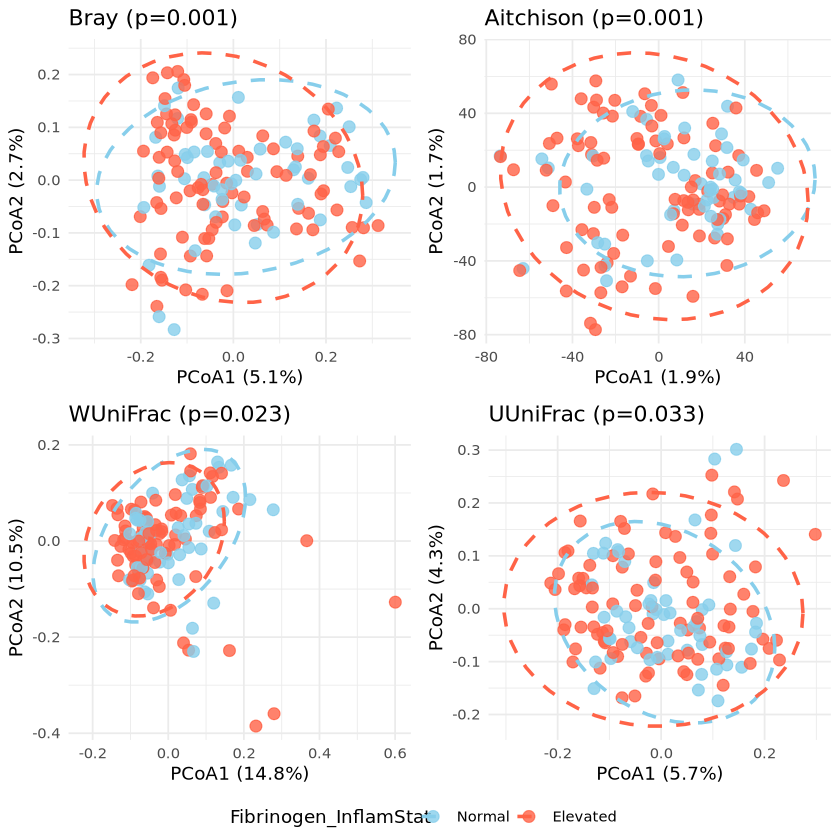

In [81]:
# ------- Adjusted Beta indices for Fibrinogen -----
# ----------- Load Confounders from File -----------
confounder_table <- read.xlsx(file.path(path.stat, "Potential_Confounders_Beta_Diversity_Inflammation.xlsx"))
fibrinogen_conf <- confounder_table %>%
  filter(inflammation == "Fibrinogen_InflamStat") %>%
  distinct(covariate) %>%
  pull(covariate)

# ----------- Define Distances -----------
distances <- list(
  Bray = bray_dist,
  Aitchison = aitchison_dist,
  WUniFrac = wunifrac_dist,
  UUniFrac = uunifrac_dist
)

pcoa_plots <- list()

# ----------- Prepare Metadata -----------
meta <- as(sample_data(ps), "data.frame")
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%Y")
meta$ExtractionDate_numeric <- as.numeric(meta$ExtractionDate - min(meta$ExtractionDate, na.rm = TRUE))
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Loop through distances and plot -----------
for (dist_name in names(distances)) {
  dist_matrix <- distances[[dist_name]]

  # Align samples
  sample_names_to_use <- intersect(rownames(meta), labels(dist_matrix))
  meta_sub <- meta[sample_names_to_use, ]
  dist_matrix <- as.matrix(dist_matrix)[sample_names_to_use, sample_names_to_use]

  # Construct formula with confounders
  covariate_formula <- paste(fibrinogen_conf, collapse = " + ")
  full_formula <- as.formula(paste("dist_matrix ~ Fibrinogen_InflamStat", covariate_formula, sep = " + "))

  # PERMANOVA
  ad <- adonis2(full_formula, data = meta_sub, permutations = 999)
  p_val <- signif(ad$`Pr(>F)`[1], 3)  # Fibrinogen p-value

  # PCoA
  pcoa_res <- ape::pcoa(as.dist(dist_matrix))
  pcoa_df <- as.data.frame(pcoa_res$vectors[, 1:2])
  pcoa_df$SampleID <- rownames(pcoa_df)
  pcoa_df <- cbind(pcoa_df, meta_sub[rownames(pcoa_df), ])

  # Plot
  p <- ggplot(pcoa_df, aes(x = Axis.1, y = Axis.2, color = Fibrinogen_InflamStat)) +
    geom_point(size = 3, alpha = 0.8) +
    stat_ellipse(level = 0.95, linetype = "dashed", size = 1) +
    labs(title = paste0(dist_name, " (p=", p_val, ")"),
         x = paste0("PCoA1 (", round(pcoa_res$values$Relative_eig[1]*100, 1), "%)"),
         y = paste0("PCoA2 (", round(pcoa_res$values$Relative_eig[2]*100, 1), "%)")) +
    theme_minimal() +
    scale_color_manual(values = c("Normal" = "skyblue", "Elevated" = "tomato")) +
    theme(legend.position = "top")

  pcoa_plots[[dist_name]] <- p
}

# ----------- Combine and Save -----------
p_combined <- ggarrange(plotlist = pcoa_plots, ncol = 2, nrow = 2, common.legend = TRUE, legend = "bottom")
print(p_combined)

ggsave(filename = file.path(path.figures, "BetaDiversity_Adjusted_Fibrinogen.tiff"),
       plot = p_combined, dpi = 300, width = 12, height = 10)
ggsave(filename = file.path(path.figures, "BetaDiversity_Adjusted_Fibrinogen.png"),
       plot = p_combined, dpi = 300, width = 12, height = 10)


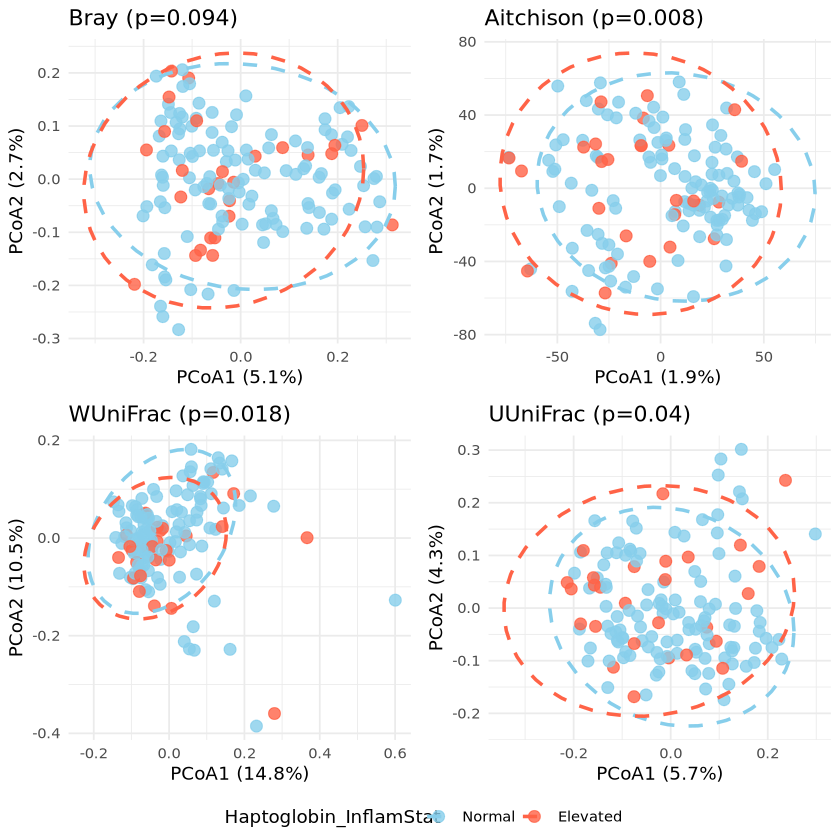

In [80]:
# ------- Adjusted Beta indices for Haptoglobin -----
# ----------- Load Confounder Table -----------
confounder_table <- read_excel(file.path(path.stat, "Potential_Confounders_Beta_Diversity_Inflammation.xlsx"))
hapto_conf <- confounder_table %>%
  filter(inflammation == "Haptoglobin_InflamStat") %>%
  distinct(covariate) %>%
  pull(covariate)

# ----------- Prepare Metadata -----------
meta <- as(sample_data(ps), "data.frame")
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%Y")
meta$ExtractionDate_numeric <- as.numeric(meta$ExtractionDate - min(meta$ExtractionDate, na.rm = TRUE))
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Define Distances -----------
distances <- list(
  Bray = bray_dist,
  Aitchison = aitchison_dist,
  WUniFrac = wunifrac_dist,
  UUniFrac = uunifrac_dist
)

pcoa_plots <- list()

# ----------- Loop through each distance metric -----------
for (dist_name in names(distances)) {
  dist_matrix <- distances[[dist_name]]
  
  # Align samples between dist and metadata
  sample_names_to_use <- intersect(rownames(meta), labels(dist_matrix))
  meta_sub <- meta[sample_names_to_use, ]
  dist_matrix <- as.matrix(dist_matrix)
  dist_matrix <- dist_matrix[sample_names_to_use, sample_names_to_use]

  # Construct formula with haptoglobin and confounders
  formula_terms <- paste(c("Haptoglobin_InflamStat", hapto_conf), collapse = " + ")
  formula <- as.formula(paste("dist_matrix ~", formula_terms))

  # PERMANOVA adjusted for confounder(s)
  ad <- adonis2(formula, data = meta_sub, permutations = 999)
  p_val <- signif(ad$`Pr(>F)`[1], 3)  # p-value for Haptoglobin

  # PCoA
  pcoa_res <- ape::pcoa(as.dist(dist_matrix))
  pcoa_df <- as.data.frame(pcoa_res$vectors[, 1:2])
  pcoa_df$SampleID <- rownames(pcoa_df)
  pcoa_df <- cbind(pcoa_df, meta_sub[rownames(pcoa_df), ])
  
  # Plot (without centroids)
  p <- ggplot(pcoa_df, aes(x = Axis.1, y = Axis.2, color = Haptoglobin_InflamStat)) +
    geom_point(size = 3, alpha = 0.8) +
    stat_ellipse(level = 0.95, linetype = "dashed", size = 1) +
    labs(title = paste0(dist_name, " (p=", p_val, ")"),
         x = paste0("PCoA1 (", round(pcoa_res$values$Relative_eig[1]*100, 1), "%)"),
         y = paste0("PCoA2 (", round(pcoa_res$values$Relative_eig[2]*100, 1), "%)")) +
    theme_minimal() +
    scale_color_manual(values = c("Normal" = "skyblue", "Elevated" = "tomato")) +
    theme(legend.position = "top")
  
  # Store plot
  pcoa_plots[[dist_name]] <- p
}

# ----------- Combine Plots into One Figure -----------
p_combined <- ggarrange(plotlist = pcoa_plots, ncol = 2, nrow = 2, common.legend = TRUE, legend = "bottom")
print(p_combined)

# ----------- Save Figure -----------
ggsave(filename = file.path(path.figures, "BetaDiversity_Adjusted_Haptoglobin.tiff"),
       plot = p_combined, dpi = 300, width = 12, height = 10)
ggsave(filename = file.path(path.figures, "BetaDiversity_Adjusted_Haptoglobin.png"),
       plot = p_combined, dpi = 300, width = 12, height = 10)
